In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split
import string 

In [5]:
data = pd.read_csv("C:/Users/Documents/IMDB Dataset.csv" , encoding = "ISO-8859-1") 

In [6]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
X = data['review']
y = data['sentiment']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

print(X_train.shape, X_test.shape)

(37500,) (12500,)


In [9]:
data = data.rename(columns={"review":"Review", "sentiment":"Sentiment"})


In [10]:
def remove_punctuations(text):
    return text.translate(str.maketrans('', '', string.punctuation))


In [11]:
data['Review'] = data['Review'].apply(remove_punctuations)


In [12]:
print(data.head())


                                              Review Sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production br br The filmin...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically theres a family where a little boy J...  negative
4  Petter Matteis Love in the Time of Money is a ...  positive


In [13]:
data.head()

,Review,Sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production br br The filmin...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically theres a family where a little boy J...,negative
4,Petter Matteis Love in the Time of Money is a ...,positive


In [14]:
print(data.head())


                                              Review Sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production br br The filmin...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically theres a family where a little boy J...  negative
4  Petter Matteis Love in the Time of Money is a ...  positive


In [15]:
data = data.rename(columns={"review":"Review", "sentiment":"Sentiment"})
def remove_punctuations(text):
    return text.translate(str.maketrans('', '', string.punctuation))

data['Review'] = data['Review'].apply(remove_punctuations)
data.head()

,Review,Sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production br br The filmin...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically theres a family where a little boy J...,negative
4,Petter Matteis Love in the Time of Money is a ...,positive


In [16]:
new_Index = ['Review', 'Sentiment']
for index in new_Index:
    data[index] = data[index].str.lower()
print(data.head())

                                              Review Sentiment
0  one of the other reviewers has mentioned that ...  positive
1  a wonderful little production br br the filmin...  positive
2  i thought this was a wonderful way to spend ti...  positive
3  basically theres a family where a little boy j...  negative
4  petter matteis love in the time of money is a ...  positive


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    data['Review'], data['Sentiment'], test_size=0.2, random_state=42
)

In [19]:
cv = CountVectorizer()

In [20]:
X_train_cv = cv.fit_transform(X_train)

In [21]:
X_test_cv = cv.transform(X_test)

In [22]:
print("Training data shape:", X_train_cv.shape)
print("Testing data shape:", X_test_cv.shape)

Training data shape: (40000, 159960)
Testing data shape: (10000, 159960)


In [23]:
print("Sample vocabulary words:", cv.get_feature_names_out()[:10])

Sample vocabulary words: ['00' '000' '00000001' '000001' '0001' '00015' '001' '0010' '002'
 '00383042']


In [24]:
cv = CountVectorizer(
    stop_words='english',       
    token_pattern=r'[a-zA-Z]+', 
    max_features=50000          
)

In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model = MultinomialNB()
model.fit(X_train_cv, y_train)

y_pred = model.predict(X_test_cv)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8495


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(stop_words='english', max_features=50000)


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[4361  600]
 [ 905 4134]]
              precision    recall  f1-score   support

    negative       0.83      0.88      0.85      4961
    positive       0.87      0.82      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=50000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

print("Accuracy with TF-IDF:", accuracy_score(y_test, y_pred))


Accuracy with TF-IDF: 0.8668


In [29]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[4352  609]
 [ 723 4316]]
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      4961
    positive       0.88      0.86      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_tfidf, y_train)
y_pred_log = log_model.predict(X_test_tfidf)

print("Accuracy with TF-IDF + Logistic Regression:", accuracy_score(y_test, y_pred_log))


Accuracy with TF-IDF + Logistic Regression: 0.8962


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


[[4360  601]
 [ 437 4602]]
              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4961
    positive       0.88      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



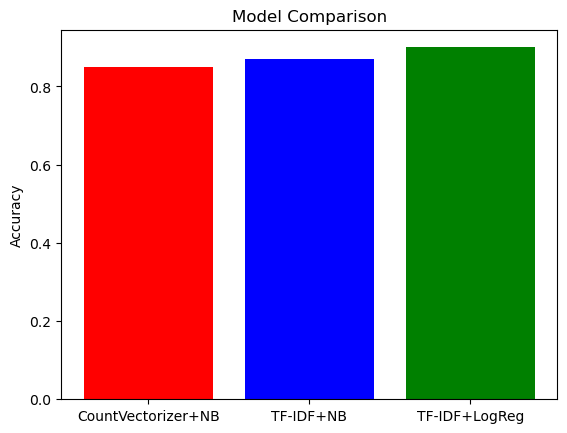

In [32]:
import matplotlib.pyplot as plt

models = ['CountVectorizer+NB', 'TF-IDF+NB', 'TF-IDF+LogReg']
accuracies = [0.85, 0.87, 0.90]

plt.bar(models, accuracies, color=['red','blue','green'])
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()
